# Explanation with SHAP

In [20]:
import joblib
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import numpy as np

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [14]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}.joblib')
x = pd.read_csv(f"../dataset/created/{pfs_dir}/x{rna_suffix}.csv")
y = pd.read_csv(f"../dataset/created/{pfs_dir}/y{rna_suffix}.csv").squeeze()

              precision    recall  f1-score   support

  Short resp       0.93      0.91      0.92        47
   Long resp       0.88      0.90      0.89        31

    accuracy                           0.91        78
   macro avg       0.90      0.91      0.91        78
weighted avg       0.91      0.91      0.91        78



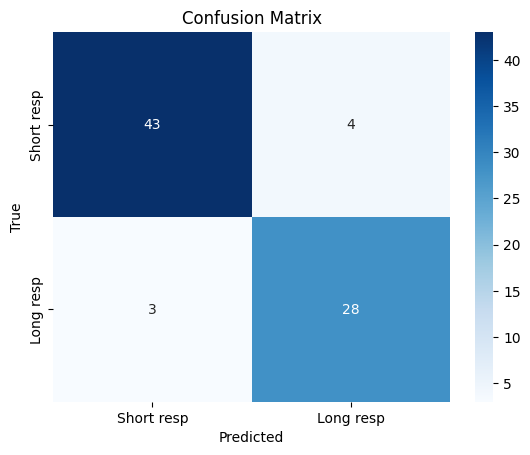

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

target_names = ['Short resp', 'Long resp']

y_pred = cross_val_predict(
    pipeline, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Calculated SHAP values

In [ ]:
model = pipeline[-1]

x_scaled = pipeline[:-1].transform(x)   # x -> preprocessed -> scaler

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]

explainer = shap.LinearExplainer(model, x_scaled)   # pass Train+Test as background
shap_values = explainer(x_scaled)                  
shap_values.feature_names = feature_names

## Plot explanation

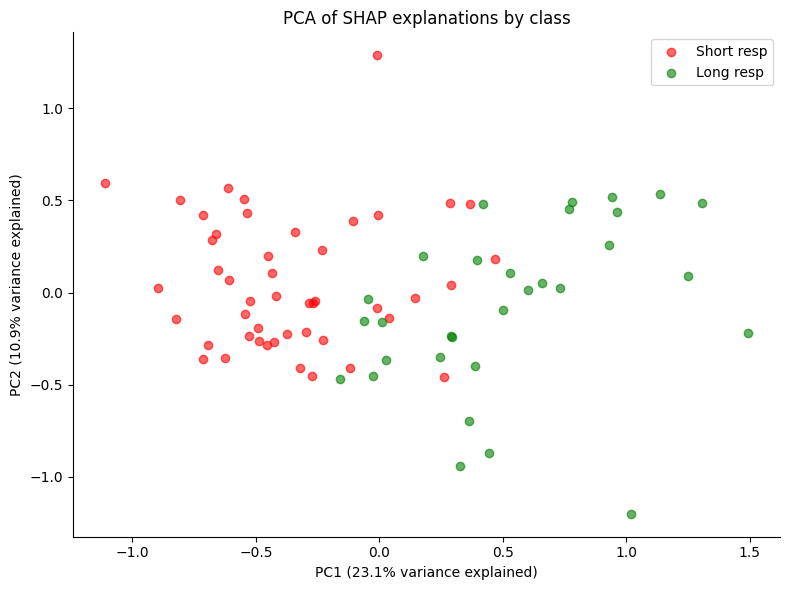

In [21]:
def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# # UMAP
# u_map = umap.UMAP(n_components=2, random_state=42)
# sv_2d = u_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


## Global interpretability

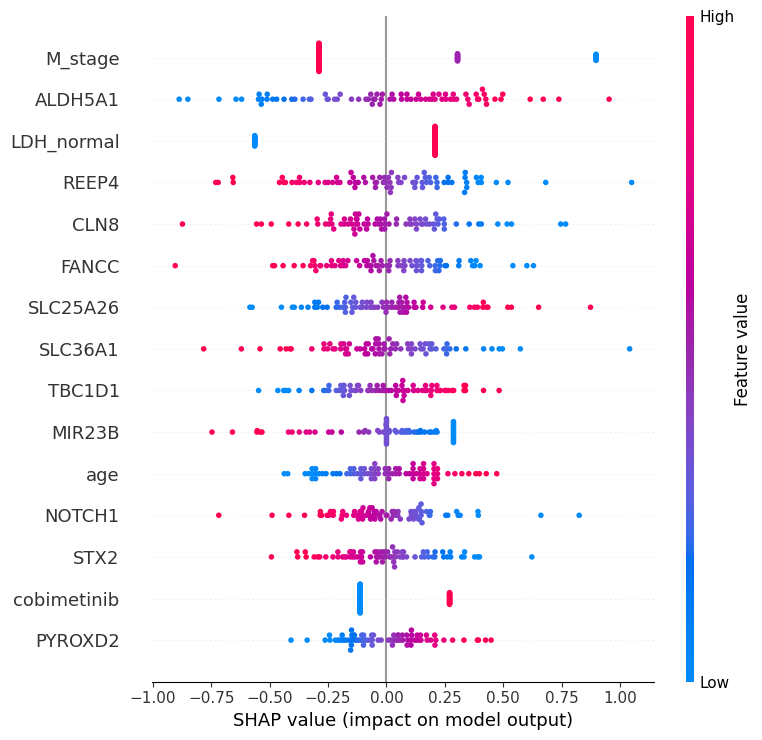

In [6]:
shap.summary_plot(shap_values, x_scaled, feature_names=feature_names, max_display=15)

## Count FP, FN, ... and their log-odds (predicted by model)

In [25]:
y_pred = model.predict(x_scaled)
misclassified = np.where(y_pred != y)[0]
print(f"Misclassified indices: {misclassified}\n")

fp = np.where((y == 0) & (y_pred == 1))[0]  # misclassified short
fn = np.where((y == 1) & (y_pred == 0))[0]  # misclassified long
tn = np.where((y == 0) & (y_pred == 0))[0]   # correctly predicted short
tp = np.where((y == 1) & (y_pred == 1))[0]   # correctly predicted long
print(f'FP (misclassified short): {fp}')
print(f'FN (misclassified long): {fn}')
print(f'TN (correct short): {tn}')
print(f'TP (correct long): {tp}')

Misclassified indices: [ 0 17 32 41]

FP (misclassified short): [ 0 17 32 41]
FN (misclassified long): []
TN (correct short): [ 3  4  5  6  8 11 14 15 16 19 21 22 25 30 34 35 36 37 39 40 44 45 46 47
 48 49 50 51 52 54 55 58 59 63 65 67 68 69 71 73 74 76 77]
TP (correct long): [ 1  2  7  9 10 12 13 18 20 23 24 26 27 28 29 31 33 38 42 43 53 56 57 60
 61 62 64 66 70 72 75]


In [27]:
log_odds = model.decision_function(x_scaled)

print(f'FP log-odds: {log_odds[fp]}')
print(f'FN log-odds: {log_odds[fn]}')
print(f'TN log-odds: {log_odds[tn]}')
print(f'TP log-odds: {log_odds[tp]}')


FP log-odds: [0.01638608 0.17785049 0.37250674 1.39388316]
FN log-odds: []
TN log-odds: [-1.27114169 -3.25459533 -3.49236493 -1.26687747 -1.45165312 -2.31507631
 -3.63919516 -1.0980495  -2.06275948 -4.43478405 -0.65791322 -4.71000469
 -0.50078758 -1.0528055  -2.0508866  -3.54613499 -1.42761631 -1.47737731
 -2.02414322 -1.4890376  -2.47929482 -3.48878855 -3.18176621 -1.66334953
 -1.80233964 -2.11583648 -3.10537697 -3.25214617 -3.66708132 -4.16111302
 -1.32533585 -1.56997878 -3.1188986  -1.52047858 -1.70201605 -2.78956523
 -3.584695   -2.08231912 -1.7384729  -0.70150915 -2.72884489 -0.55958551
 -1.8215907 ]
TP log-odds: [3.12676831 1.65213287 1.73760323 4.61748902 1.85030423 3.82551075
 1.35027281 1.40265304 1.65949011 0.62666577 1.35707519 0.5597821
 3.50936438 0.35359717 1.78718679 2.07267043 0.45303752 0.04940573
 0.27939263 2.02892924 1.26288041 0.94611237 1.48291159 4.38146719
 1.46446901 1.64041739 2.79855503 4.03731945 3.69757024 1.16124287
 3.51331881]


## Local interpretability

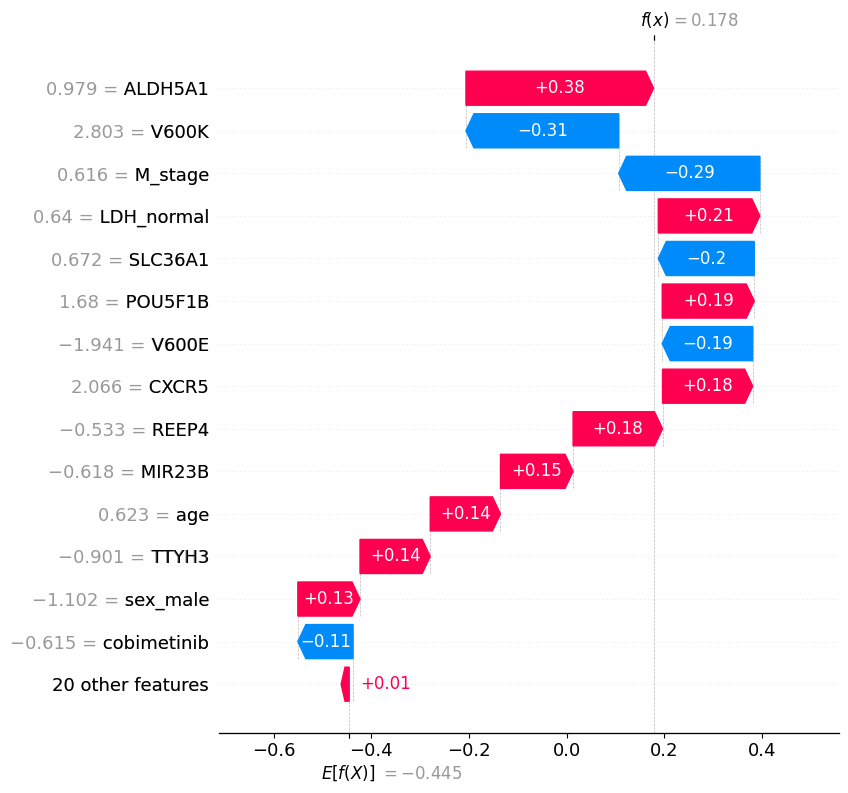

In [28]:
shap.plots.waterfall(shap_values[fp[1]], max_display=15)

In [34]:
shap.initjs()
shap.plots.force(shap_values[tn[11]])